In [1]:
!pip install shap pulp joblib

Defaulting to user installation because normal site-packages is not writeable
  Using cached pulp-3.3.2-py3-none-any.whl.metadata (8.6 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached pulp-3.3.2-py3-none-any.whl (16.4 MB)

   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   ------------- -------------------------- 1/3 [pulp]
   -------------------------- -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [9]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap
import pulp

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [10]:
rf_model = joblib.load("models/random_forest_model.pkl")
X_test = joblib.load("models/X_test.pkl")
y_test = joblib.load("models/y_test.pkl")

test_result = pd.read_csv("results/test_predictions.csv")
player_risk_summary = pd.read_csv("results/player_risk_summary.csv")
df = pd.read_csv("results/feature_dataset.csv")

print("모델 및 데이터 불러오기 완료")
print("X_test shape:", X_test.shape)
print("test_result shape:", test_result.shape)
print("player_risk_summary shape:", player_risk_summary.shape)

모델 및 데이터 불러오기 완료
X_test shape: (286, 20)
test_result shape: (286, 41)
player_risk_summary shape: (9, 8)


In [11]:
print("[X_test columns]")
print(X_test.columns.tolist())

print("\n[test_result columns]")
print(test_result.columns.tolist())

print("\n[player_risk_summary columns]")
print(player_risk_summary.columns.tolist())

[X_test columns]
['recent3_weighted_FP_per_MIN', 'recent3_TS_avg', 'recent3_TOV_avg', 'recent3_PTS_avg', 'recent3_REB_avg', 'recent3_AST_avg', 'recent3_STL_avg', 'recent3_BLK_avg', 'recent3_MIN_avg', 'recent5_MIN_sum', 'recent5_high_MIN_count', 'rest_days_fixed', 'back_to_back', 'recent3_USG_Proxy_per_MIN_avg', 'recent5_USG_Proxy_sum', 'home', 'starter_flag', 'Pos', 'Opponent', 'season']

[test_result columns]
['Player', 'season', 'Date_fixed', 'Team', 'Opponent', 'home', 'Status', 'starter_flag', 'Pos', 'W/L', 'current_MIN', 'current_FP', 'current_FP_per_MIN', 'target_FP_per_MIN_drop_5', 'target_FP_per_MIN_drop_rate', 'recent3_weighted_FP_per_MIN', 'recent3_TS_avg', 'recent3_TOV_avg', 'recent3_PTS_avg', 'recent3_REB_avg', 'recent3_AST_avg', 'recent3_STL_avg', 'recent3_BLK_avg', 'recent3_MIN_avg', 'recent5_MIN_sum', 'recent5_high_MIN_count', 'rest_days_fixed', 'back_to_back', 'recent3_USG_Proxy_per_MIN_avg', 'recent5_USG_Proxy_sum', 'recent5_MIN_sum_bin', 'recent5_USG_Proxy_sum_bin', '

In [12]:
#SHAP 분석용 전처리 데이터 만들기
# Pipeline에서 전처리기와 RandomForest 모델 분리
preprocessor = rf_model.named_steps["preprocessor"]
rf_clf = rf_model.named_steps["model"]

# X_test를 모델 입력 형태로 변환
X_test_transformed = preprocessor.transform(X_test)

# 희소행렬이면 dense array로 변환
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

# feature name 추출
numeric_features = preprocessor.transformers_[0][2]
categorical_features = preprocessor.transformers_[1][2]

cat_encoder = preprocessor.named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = list(numeric_features) + cat_feature_names

X_test_shap = pd.DataFrame(
    X_test_transformed,
    columns=all_feature_names,
    index=X_test.index
)

display(X_test_shap.head())

,recent3_weighted_FP_per_MIN,recent3_TS_avg,recent3_TOV_avg,recent3_PTS_avg,recent3_REB_avg,recent3_AST_avg,recent3_STL_avg,recent3_BLK_avg,recent3_MIN_avg,recent5_MIN_sum,recent5_high_MIN_count,rest_days_fixed,back_to_back,recent3_USG_Proxy_per_MIN_avg,recent5_USG_Proxy_sum,home,starter_flag,Pos_C,Pos_PF,Pos_PG,Pos_SF,Pos_SG,Opponent_Anyang KGC,Opponent_Goyang Sono Skygunners,Opponent_Jeonju KCC Egis,Opponent_Korea Gas Corporation,Opponent_Seoul SK,Opponent_Seoul Samsung Thunders,Opponent_Suwon KT Sonicboom,Opponent_Ulsan Mobis Phoebus,Opponent_Wonju Dongbu Promy,season_24-25
28,2.484357,-0.439494,1.744563,1.025664,3.505174,0.166666,3.362430,4.679200,0.680243,0.790046,0.867180,-0.602414,-0.311588,1.152096,1.474414,1.132620,0.505525,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
29,2.186164,-0.627827,2.135998,0.963029,2.532148,0.318389,3.820903,1.952347,0.450042,0.784821,0.867180,2.067105,-0.311588,1.457301,1.566327,-0.882909,0.505525,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30,2.701463,0.629970,2.920043,2.588340,3.416548,0.774013,2.448229,0.584825,0.818151,0.722865,0.867180,-0.602414,-0.311588,2.379553,1.821257,1.132620,0.505525,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
31,2.214937,0.811577,2.920043,1.588250,2.443788,1.077914,1.075556,0.584825,0.178275,0.268269,0.189039,2.067105,-0.311588,1.649713,1.609683,-0.882909,-1.978141,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,1.765030,0.105327,1.744563,0.650607,1.736109,0.926191,-0.755590,-0.778602,-0.775815,-0.195284,0.189039,-1.492253,3.209361,0.886699,1.431058,-0.882909,0.505525,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


In [13]:
explainer = shap.TreeExplainer(rf_clf)

shap_values = explainer.shap_values(X_test_shap)

# 이진분류일 경우 class 1, 즉 하락 위험 class의 SHAP 값 사용
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    # 최신 shap 버전에서는 3차원 배열로 나올 수 있음
    if len(shap_values.shape) == 3:
        shap_values_class1 = shap_values[:, :, 1]
    else:
        shap_values_class1 = shap_values

print("SHAP 계산 완료")
print("SHAP shape:", shap_values_class1.shape)

SHAP 계산 완료
SHAP shape: (286, 32)


In [14]:
shap_importance_df = pd.DataFrame({
    "feature": all_feature_names,
    "mean_abs_shap": np.abs(shap_values_class1).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_df.head(20))

shap_importance_df.to_csv(
    "results/shap_feature_importance.csv",
    index=False,
    encoding="utf-8-sig"
)

,feature,mean_abs_shap
4,recent3_REB_avg,0.025034
0,recent3_weighted_FP_per_MIN,0.022861
16,starter_flag,0.021089
6,recent3_STL_avg,0.019352
20,Pos_SF,0.015182
3,recent3_PTS_avg,0.011702
1,recent3_TS_avg,0.011401
13,recent3_USG_Proxy_per_MIN_avg,0.010616
8,recent3_MIN_avg,0.008895
9,recent5_MIN_sum,0.008582


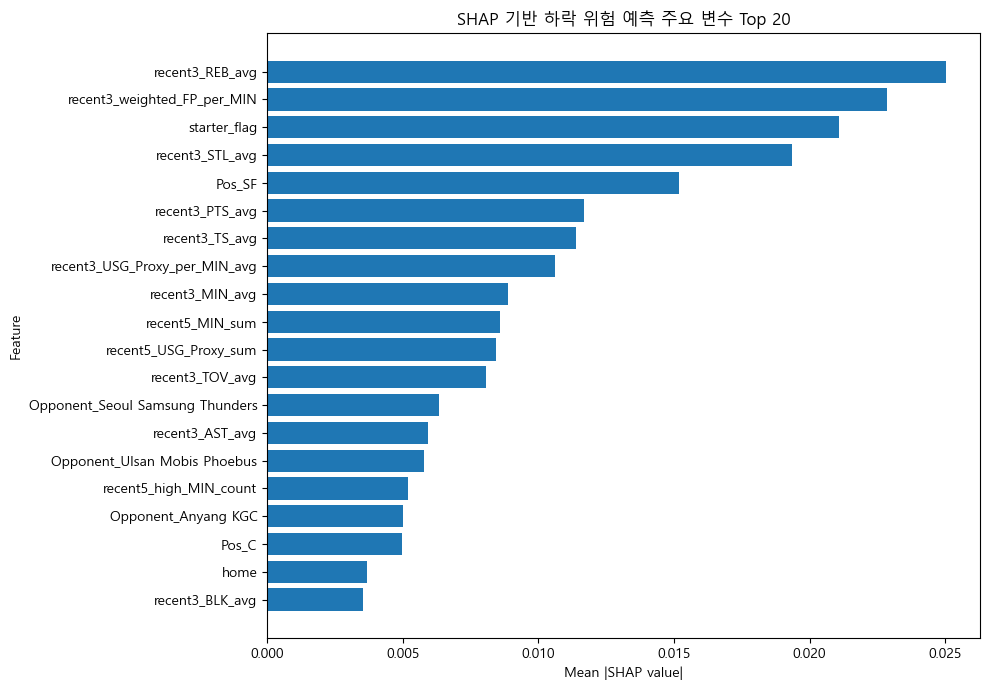

In [15]:
top_n = 20
plot_df = shap_importance_df.head(top_n).sort_values("mean_abs_shap", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.title("SHAP 기반 하락 위험 예측 주요 변수 Top 20")
plt.tight_layout()
plt.savefig("figures/shap_feature_importance_top20.png", dpi=300, bbox_inches="tight")
plt.show()

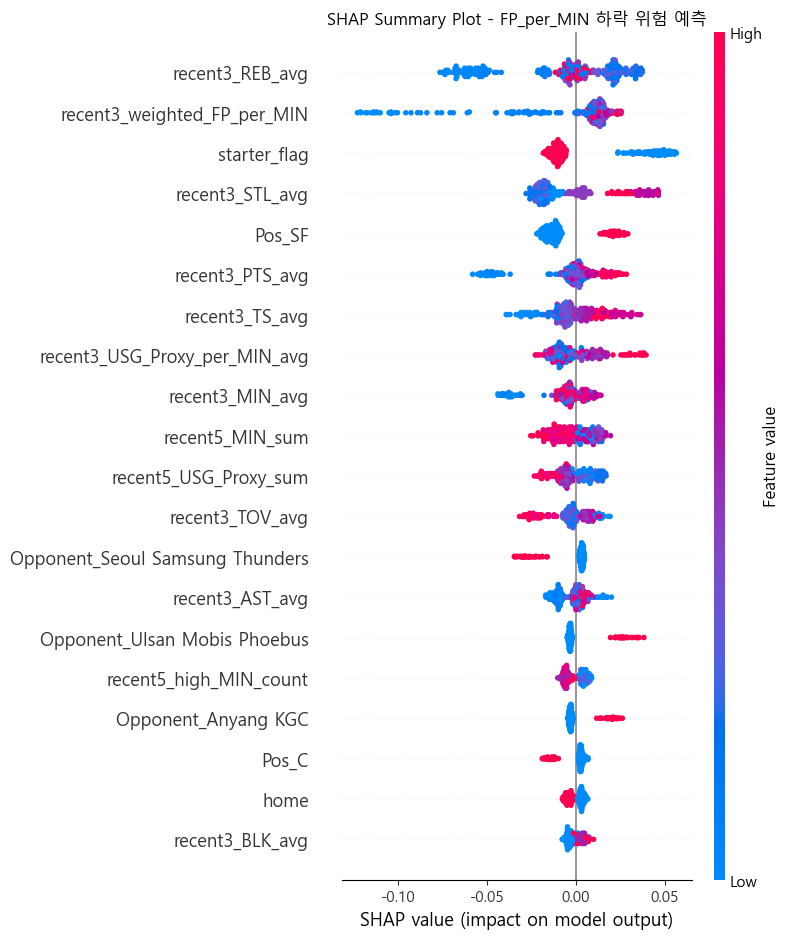

In [16]:
shap.summary_plot(
    shap_values_class1,
    X_test_shap,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot - FP_per_MIN 하락 위험 예측")
plt.tight_layout()
plt.savefig("figures/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
shap_contrib_df = pd.DataFrame(
    shap_values_class1,
    columns=all_feature_names,
    index=X_test.index
)

# test_result와 index를 맞추기 위해 복사
shap_case_result = test_result.copy()

# X_test index 순서와 test_result 행 순서가 다를 수 있으므로 안전하게 정렬
# 일반적으로 저장된 test_result가 X_test 순서와 같다면 그대로 사용 가능
shap_case_result = shap_case_result.reset_index(drop=True)

shap_contrib_reset = shap_contrib_df.reset_index(drop=True)

# 각 경기별 하락 위험 증가 요인 Top 3 추출
top_positive_features = []
top_positive_values = []

for i in range(len(shap_contrib_reset)):
    row = shap_contrib_reset.iloc[i]
    positive_row = row.sort_values(ascending=False).head(3)
    
    top_positive_features.append(", ".join(positive_row.index.tolist()))
    top_positive_values.append(", ".join([f"{v:.4f}" for v in positive_row.values]))

shap_case_result["shap_top_positive_features"] = top_positive_features
shap_case_result["shap_top_positive_values"] = top_positive_values

display(shap_case_result[[
    "Player",
    "Date_fixed",
    "Opponent",
    "pred_drop_prob_rf",
    "risk_level",
    "shap_top_positive_features",
    "shap_top_positive_values"
]].sort_values("pred_drop_prob_rf", ascending=False).head(20))

shap_case_result.to_csv(
    "results/test_predictions_with_shap.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,Date_fixed,Opponent,pred_drop_prob_rf,risk_level,shap_top_positive_features,shap_top_positive_values
235,정인덕,2026-04-08,Ulsan Mobis Phoebus,0.683957,높음,"starter_flag, recent3_REB_avg, Opponent_Ulsan ...","0.0559, 0.0342, 0.0265"
223,정인덕,2026-02-08,Anyang KGC,0.665021,높음,"recent3_STL_avg, recent3_REB_avg, Opponent_Any...","0.0460, 0.0252, 0.0240"
219,정인덕,2026-01-28,Wonju Dongbu Promy,0.656632,높음,"starter_flag, recent3_STL_avg, recent3_REB_avg","0.0427, 0.0403, 0.0337"
174,윤원상,2025-12-28,Anyang KGC,0.624259,높음,"starter_flag, recent3_REB_avg, recent3_TS_avg","0.0346, 0.0259, 0.0224"
86,양준석,2025-12-13,Seoul SK,0.621066,높음,"recent3_STL_avg, starter_flag, recent3_REB_avg","0.0362, 0.0309, 0.0235"
175,윤원상,2025-12-31,Ulsan Mobis Phoebus,0.611533,높음,"starter_flag, recent3_REB_avg, Opponent_Ulsan ...","0.0414, 0.0291, 0.0224"
171,유기상,2026-04-08,Ulsan Mobis Phoebus,0.604745,높음,"recent3_TS_avg, Opponent_Ulsan Mobis Phoebus, ...","0.0345, 0.0290, 0.0256"
280,허일영,2026-02-05,Seoul Samsung Thunders,0.599212,높음,"starter_flag, recent3_REB_avg, recent3_TS_avg","0.0497, 0.0342, 0.0271"
34,Assem Marei,2026-03-08,Seoul SK,0.598632,높음,"recent3_USG_Proxy_per_MIN_avg, recent3_PTS_avg...","0.0394, 0.0283, 0.0245"
104,양준석,2026-03-08,Seoul SK,0.595838,높음,"recent3_STL_avg, recent3_REB_avg, recent3_weig...","0.0461, 0.0255, 0.0164"


In [18]:
# 선수별 평균 SHAP 값 계산
shap_player_df = shap_contrib_reset.copy()
shap_player_df["Player"] = shap_case_result["Player"].values

player_shap_summary_list = []

for player, group in shap_player_df.groupby("Player"):
    mean_shap = group.drop(columns=["Player"]).mean().sort_values(ascending=False)
    top_features = mean_shap.head(5)
    
    player_shap_summary_list.append({
        "Player": player,
        "top1_feature": top_features.index[0],
        "top1_mean_shap": top_features.iloc[0],
        "top2_feature": top_features.index[1],
        "top2_mean_shap": top_features.iloc[1],
        "top3_feature": top_features.index[2],
        "top3_mean_shap": top_features.iloc[2],
        "top4_feature": top_features.index[3],
        "top4_mean_shap": top_features.iloc[3],
        "top5_feature": top_features.index[4],
        "top5_mean_shap": top_features.iloc[4],
    })

player_shap_summary = pd.DataFrame(player_shap_summary_list)

# 평균 예측 하락 확률 붙이기
if "avg_pred_drop_prob_rf" in player_risk_summary.columns:
    player_shap_summary = player_shap_summary.merge(
        player_risk_summary[["Player", "avg_pred_drop_prob_rf", "actual_drop_rate"]],
        on="Player",
        how="left"
    )

player_shap_summary = player_shap_summary.sort_values(
    "avg_pred_drop_prob_rf",
    ascending=False
)

display(player_shap_summary)

player_shap_summary.to_csv(
    "results/player_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,top1_feature,top1_mean_shap,top2_feature,top2_mean_shap,top3_feature,top3_mean_shap,top4_feature,top4_mean_shap,top5_feature,top5_mean_shap,avg_pred_drop_prob_rf,actual_drop_rate
3,양홍석,recent3_REB_avg,0.013858,recent5_MIN_sum,0.011679,recent3_weighted_FP_per_MIN,0.010010,starter_flag,0.008107,recent5_high_MIN_count,0.005703,0.500962,0.550000
5,윤원상,starter_flag,0.037385,recent5_MIN_sum,0.010410,recent5_USG_Proxy_sum,0.009180,recent3_weighted_FP_per_MIN,0.008458,recent3_TS_avg,0.006398,0.494159,0.523810
2,양준석,recent3_weighted_FP_per_MIN,0.012868,recent3_REB_avg,0.005471,Pos_C,0.003580,recent3_USG_Proxy_per_MIN_avg,0.002481,recent3_AST_avg,0.002221,0.487753,0.486486
0,Assem Marei,recent3_STL_avg,0.020207,recent3_weighted_FP_per_MIN,0.013220,recent3_PTS_avg,0.010296,recent3_USG_Proxy_per_MIN_avg,0.005000,recent3_AST_avg,0.003736,0.487570,0.452381
8,허일영,starter_flag,0.028132,recent5_USG_Proxy_sum,0.009933,recent5_MIN_sum,0.009298,recent5_high_MIN_count,0.005423,Pos_C,0.002531,0.477033,0.555556
1,Tamayo,recent3_weighted_FP_per_MIN,0.011737,recent3_REB_avg,0.007831,recent3_PTS_avg,0.007274,Pos_C,0.004082,recent3_USG_Proxy_per_MIN_avg,0.001736,0.470238,0.424242
6,정인덕,Pos_SF,0.016492,recent5_USG_Proxy_sum,0.009720,recent3_TS_avg,0.005268,starter_flag,0.003072,Pos_C,0.002661,0.463219,0.465116
7,최형찬,starter_flag,0.032132,recent5_MIN_sum,0.004565,recent5_USG_Proxy_sum,0.004327,recent5_high_MIN_count,0.003587,recent3_TOV_avg,0.003293,0.428182,0.531250
4,유기상,recent3_PTS_avg,0.005147,recent3_TS_avg,0.004102,Pos_C,0.003082,recent3_BLK_avg,0.000779,Opponent_Ulsan Mobis Phoebus,0.000711,0.419690,0.500000


In [19]:
def shap_strategy_from_features(features):
    features_text = " ".join([str(f) for f in features])
    
    if "MIN" in features_text or "minutes" in features_text:
        return "최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요"
    elif "FP_per_MIN" in features_text:
        return "최근 분당 생산성 변화가 크게 작용하므로 평균 회귀 가능성 고려 필요"
    elif "TS" in features_text or "PTS" in features_text:
        return "최근 득점/효율 변동이 크게 작용하므로 슈팅 의존도 및 공격 부담 점검 필요"
    elif "Opponent" in features_text:
        return "상대팀 요인이 크게 작용하므로 매치업 기반 로테이션 조정 필요"
    elif "Pos" in features_text:
        return "포지션 효과가 크게 작용하므로 포지션별 역할 및 대체 선수 활용 검토 필요"
    elif "starter" in features_text:
        return "선발 여부 관련 요인이 작용하므로 선발/벤치 역할 안정화 필요"
    else:
        return "복합 요인에 의한 하락 위험으로 경기 중 모니터링 필요"

player_shap_summary["management_strategy"] = player_shap_summary.apply(
    lambda row: shap_strategy_from_features([
        row["top1_feature"],
        row["top2_feature"],
        row["top3_feature"]
    ]),
    axis=1
)

display(player_shap_summary[[
    "Player",
    "avg_pred_drop_prob_rf",
    "actual_drop_rate",
    "top1_feature",
    "top2_feature",
    "top3_feature",
    "management_strategy"
]])

player_shap_summary.to_csv(
    "results/player_shap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,avg_pred_drop_prob_rf,actual_drop_rate,top1_feature,top2_feature,top3_feature,management_strategy
3,양홍석,0.500962,0.550000,recent3_REB_avg,recent5_MIN_sum,recent3_weighted_FP_per_MIN,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
5,윤원상,0.494159,0.523810,starter_flag,recent5_MIN_sum,recent5_USG_Proxy_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
2,양준석,0.487753,0.486486,recent3_weighted_FP_per_MIN,recent3_REB_avg,Pos_C,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
0,Assem Marei,0.487570,0.452381,recent3_STL_avg,recent3_weighted_FP_per_MIN,recent3_PTS_avg,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
8,허일영,0.477033,0.555556,starter_flag,recent5_USG_Proxy_sum,recent5_MIN_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
1,Tamayo,0.470238,0.424242,recent3_weighted_FP_per_MIN,recent3_REB_avg,recent3_PTS_avg,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
6,정인덕,0.463219,0.465116,Pos_SF,recent5_USG_Proxy_sum,recent3_TS_avg,최근 득점/효율 변동이 크게 작용하므로 슈팅 의존도 및 공격 부담 점검 필요
7,최형찬,0.428182,0.531250,starter_flag,recent5_MIN_sum,recent5_USG_Proxy_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요
4,유기상,0.419690,0.500000,recent3_PTS_avg,recent3_TS_avg,Pos_C,최근 득점/효율 변동이 크게 작용하므로 슈팅 의존도 및 공격 부담 점검 필요


In [21]:
# MILP용 선수 단위 데이터 생성

required_cols = [
    "Player",
    "pred_drop_prob_rf",
    "recent3_weighted_FP_per_MIN",
    "recent5_MIN_sum"
]

missing_cols = [col for col in required_cols if col not in test_result.columns]
print("missing columns:", missing_cols)

milp_base = (
    test_result
    .groupby("Player")
    .agg(
        avg_pred_drop_prob=("pred_drop_prob_rf", "mean"),
        actual_drop_rate=("target_FP_per_MIN_drop_5", "mean"),
        expected_fp_per_min=("recent3_weighted_FP_per_MIN", "mean"),
        avg_recent5_min_sum=("recent5_MIN_sum", "mean"),
        avg_recent3_min=("recent3_MIN_avg", "mean") if "recent3_MIN_avg" in test_result.columns else ("recent5_MIN_sum", lambda x: x.mean() / 5),
        starter_rate=("starter_flag", "mean"),
        main_pos=("Pos", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "Unknown")
    )
    .reset_index()
)

# 위험 보정 생산성
lambda_risk = 0.5

milp_base["risk_adjusted_score"] = (
    milp_base["expected_fp_per_min"] - lambda_risk * milp_base["avg_pred_drop_prob"]
)

display(milp_base.sort_values("avg_pred_drop_prob", ascending=False))

missing columns: []


,Player,avg_pred_drop_prob,actual_drop_rate,expected_fp_per_min,avg_recent5_min_sum,avg_recent3_min,starter_rate,main_pos,risk_adjusted_score
3,양홍석,0.500962,0.550000,0.787950,112.278000,22.088500,0.600000,C,0.537469
5,윤원상,0.494159,0.523810,0.745524,78.353333,15.129381,0.142857,PG,0.498444
2,양준석,0.487753,0.486486,0.788027,145.643784,29.188595,0.891892,PG,0.544150
0,Assem Marei,0.487570,0.452381,1.566452,144.119048,28.891524,0.904762,C,1.322667
8,허일영,0.477033,0.555556,0.578944,85.038333,17.217667,0.333333,PF,0.340428
1,Tamayo,0.470238,0.424242,0.912212,144.735455,28.996515,0.848485,PF,0.677093
6,정인덕,0.463219,0.465116,0.460488,127.408372,25.261860,0.720930,SF,0.228879
7,최형찬,0.428182,0.531250,0.574469,78.621250,15.627594,0.250000,PG,0.360378
4,유기상,0.419690,0.500000,0.611825,151.737250,30.368300,0.950000,SG,0.401980


In [22]:
# 기본 최소/최대 출전시간 설정
milp_df = milp_base.copy()

# 최근 평균 출전시간 기준
milp_df["base_minutes"] = milp_df["avg_recent3_min"]

# 이상치 방지
milp_df["base_minutes"] = milp_df["base_minutes"].clip(lower=5, upper=34)

# 선발 비율에 따른 최소 출전시간
milp_df["min_minutes"] = 0

milp_df.loc[milp_df["starter_rate"] >= 0.7, "min_minutes"] = 18
milp_df.loc[(milp_df["starter_rate"] >= 0.3) & (milp_df["starter_rate"] < 0.7), "min_minutes"] = 8
milp_df.loc[milp_df["starter_rate"] < 0.3, "min_minutes"] = 0

# 최대 출전시간은 최근 평균 + 6분, 최대 36분
milp_df["max_minutes"] = (milp_df["base_minutes"] + 6).clip(upper=36)

# 하락 위험이 높은 선수는 최대 출전시간 제한
milp_df.loc[milp_df["avg_pred_drop_prob"] >= 0.55, "max_minutes"] = (
    milp_df["base_minutes"] - 2
).clip(lower=10, upper=32)

# 최소가 최대보다 커지는 경우 보정
milp_df["min_minutes"] = np.minimum(milp_df["min_minutes"], milp_df["max_minutes"])

display(milp_df[[
    "Player",
    "main_pos",
    "starter_rate",
    "avg_pred_drop_prob",
    "expected_fp_per_min",
    "risk_adjusted_score",
    "base_minutes",
    "min_minutes",
    "max_minutes"
]].sort_values("risk_adjusted_score", ascending=False))

,Player,main_pos,starter_rate,avg_pred_drop_prob,expected_fp_per_min,risk_adjusted_score,base_minutes,min_minutes,max_minutes
0,Assem Marei,C,0.904762,0.487570,1.566452,1.322667,28.891524,18.0,34.891524
1,Tamayo,PF,0.848485,0.470238,0.912212,0.677093,28.996515,18.0,34.996515
2,양준석,PG,0.891892,0.487753,0.788027,0.544150,29.188595,18.0,35.188595
3,양홍석,C,0.600000,0.500962,0.787950,0.537469,22.088500,8.0,28.088500
5,윤원상,PG,0.142857,0.494159,0.745524,0.498444,15.129381,0.0,21.129381
4,유기상,SG,0.950000,0.419690,0.611825,0.401980,30.368300,18.0,36.000000
7,최형찬,PG,0.250000,0.428182,0.574469,0.360378,15.627594,0.0,21.627594
8,허일영,PF,0.333333,0.477033,0.578944,0.340428,17.217667,8.0,23.217667
6,정인덕,SF,0.720930,0.463219,0.460488,0.228879,25.261860,18.0,31.261860


In [23]:
# MILP 모델 생성
model = pulp.LpProblem("KBL_Rotation_Optimization", pulp.LpMaximize)

# 의사결정변수: 선수별 권장 출전시간
minutes = {
    row["Player"]: pulp.LpVariable(
        f"minutes_{row['Player']}",
        lowBound=float(row["min_minutes"]),
        upBound=float(row["max_minutes"]),
        cat="Continuous"
    )
    for _, row in milp_df.iterrows()
}

# 목적함수: 위험 보정 생산성 최대화
model += pulp.lpSum(
    float(row["risk_adjusted_score"]) * minutes[row["Player"]]
    for _, row in milp_df.iterrows()
)

# 총 출전시간 200분 제약
model += pulp.lpSum(minutes[player] for player in minutes) == 200

# 포지션별 최소 출전시간 제약
guards = milp_df[milp_df["main_pos"].isin(["PG", "SG"])]["Player"].tolist()
forwards = milp_df[milp_df["main_pos"].isin(["SF", "PF"])]["Player"].tolist()
centers = milp_df[milp_df["main_pos"].isin(["C"])]["Player"].tolist()

if len(guards) > 0:
    model += pulp.lpSum(minutes[p] for p in guards) >= 55

if len(forwards) > 0:
    model += pulp.lpSum(minutes[p] for p in forwards) >= 55

if len(centers) > 0:
    model += pulp.lpSum(minutes[p] for p in centers) >= 25

# 최적화 실행
solver = pulp.PULP_CBC_CMD(msg=False)
status = model.solve(solver)

print("MILP Status:", pulp.LpStatus[model.status])
print("Objective Value:", pulp.value(model.objective))

MILP Status: Optimal
Objective Value: 129.38663609566606


In [24]:
rotation_result = []

for _, row in milp_df.iterrows():
    player = row["Player"]
    rec_minutes = minutes[player].value()
    
    rotation_result.append({
        "Player": player,
        "Pos": row["main_pos"],
        "starter_rate": row["starter_rate"],
        "avg_pred_drop_prob": row["avg_pred_drop_prob"],
        "actual_drop_rate": row["actual_drop_rate"],
        "expected_fp_per_min": row["expected_fp_per_min"],
        "risk_adjusted_score": row["risk_adjusted_score"],
        "base_minutes": row["base_minutes"],
        "min_minutes": row["min_minutes"],
        "max_minutes": row["max_minutes"],
        "recommended_minutes": rec_minutes,
        "minute_change": rec_minutes - row["base_minutes"]
    })

rotation_result = pd.DataFrame(rotation_result)
rotation_result = rotation_result.sort_values("recommended_minutes", ascending=False)

display(rotation_result)

rotation_result.to_csv(
    "results/milp_rotation_result.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,Pos,starter_rate,avg_pred_drop_prob,actual_drop_rate,expected_fp_per_min,risk_adjusted_score,base_minutes,min_minutes,max_minutes,recommended_minutes,minute_change
2,양준석,PG,0.891892,0.487753,0.486486,0.788027,0.544150,29.188595,18.0,35.188595,35.188595,6.000000
1,Tamayo,PF,0.848485,0.470238,0.424242,0.912212,0.677093,28.996515,18.0,34.996515,34.996515,6.000000
0,Assem Marei,C,0.904762,0.487570,0.452381,1.566452,1.322667,28.891524,18.0,34.891524,34.891524,6.000000
3,양홍석,C,0.600000,0.500962,0.550000,0.787950,0.537469,22.088500,8.0,28.088500,28.088500,6.000000
5,윤원상,PG,0.142857,0.494159,0.523810,0.745524,0.498444,15.129381,0.0,21.129381,21.129381,6.000000
4,유기상,SG,0.950000,0.419690,0.500000,0.611825,0.401980,30.368300,18.0,36.000000,19.705485,-10.662815
6,정인덕,SF,0.720930,0.463219,0.465116,0.460488,0.228879,25.261860,18.0,31.261860,18.000000,-7.261860
8,허일영,PF,0.333333,0.477033,0.555556,0.578944,0.340428,17.217667,8.0,23.217667,8.000000,-9.217667
7,최형찬,PG,0.250000,0.428182,0.531250,0.574469,0.360378,15.627594,0.0,21.627594,0.000000,-15.627594


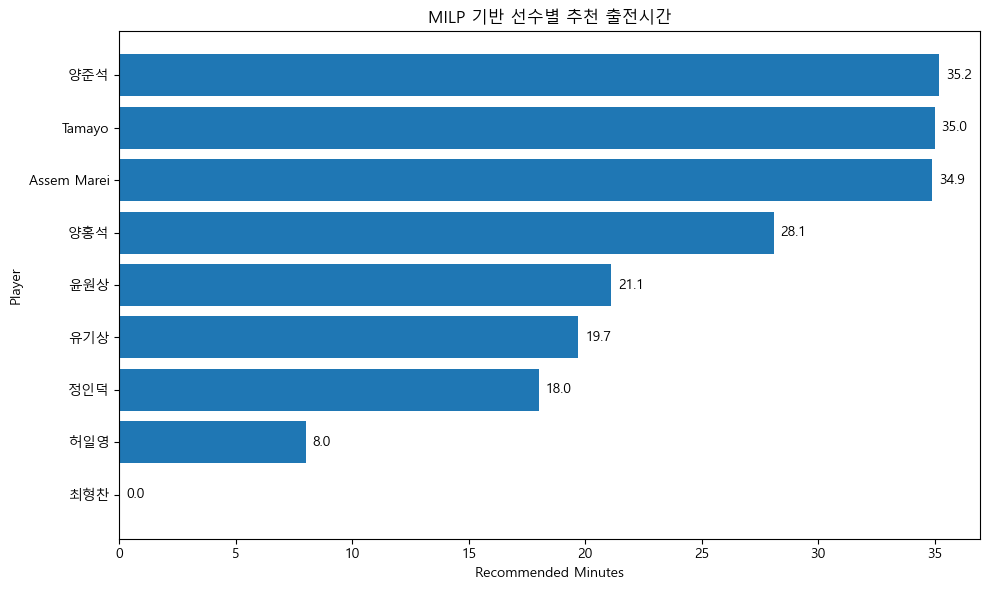

In [25]:
plot_df = rotation_result.sort_values("recommended_minutes", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Player"], plot_df["recommended_minutes"])

plt.xlabel("Recommended Minutes")
plt.ylabel("Player")
plt.title("MILP 기반 선수별 추천 출전시간")

for i, v in enumerate(plot_df["recommended_minutes"]):
    plt.text(v + 0.3, i, f"{v:.1f}", va="center")

plt.tight_layout()
plt.savefig("figures/milp_recommended_minutes.png", dpi=300, bbox_inches="tight")
plt.show()

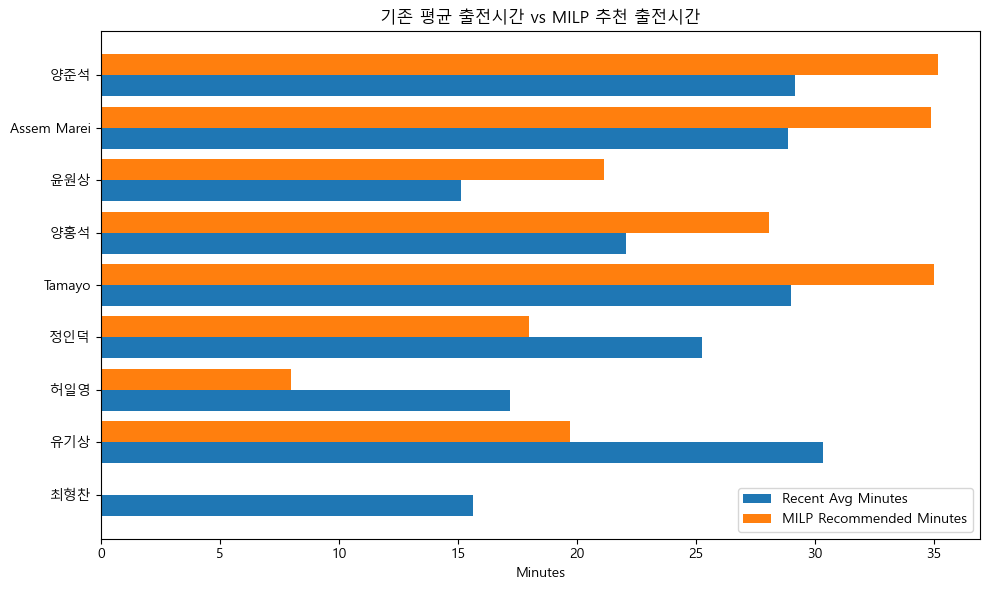

In [26]:
compare_df = rotation_result.sort_values("minute_change", ascending=True)

plt.figure(figsize=(10, 6))

y_pos = np.arange(len(compare_df))

plt.barh(y_pos - 0.2, compare_df["base_minutes"], height=0.4, label="Recent Avg Minutes")
plt.barh(y_pos + 0.2, compare_df["recommended_minutes"], height=0.4, label="MILP Recommended Minutes")

plt.yticks(y_pos, compare_df["Player"])
plt.xlabel("Minutes")
plt.title("기존 평균 출전시간 vs MILP 추천 출전시간")
plt.legend()

plt.tight_layout()
plt.savefig("figures/milp_minutes_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

In [27]:
def milp_management_action(row):
    if row["avg_pred_drop_prob"] >= 0.55 and row["minute_change"] < 0:
        return "하락 위험이 높아 출전시간 축소 권장"
    elif row["avg_pred_drop_prob"] >= 0.55 and row["minute_change"] >= 0:
        return "하락 위험은 높지만 대체 자원 부족으로 경기 중 모니터링 필요"
    elif row["avg_pred_drop_prob"] >= 0.45 and row["minute_change"] < 0:
        return "중간 위험군으로 소폭 출전시간 관리 권장"
    elif row["avg_pred_drop_prob"] < 0.45 and row["minute_change"] > 0:
        return "상대적으로 안정적이므로 출전시간 확대 가능"
    else:
        return "기존 로테이션 유지 가능"

rotation_result["milp_management_action"] = rotation_result.apply(
    milp_management_action,
    axis=1
)

display(rotation_result[[
    "Player",
    "Pos",
    "avg_pred_drop_prob",
    "base_minutes",
    "recommended_minutes",
    "minute_change",
    "milp_management_action"
]])

rotation_result.to_csv(
    "results/milp_rotation_result.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,Pos,avg_pred_drop_prob,base_minutes,recommended_minutes,minute_change,milp_management_action
2,양준석,PG,0.487753,29.188595,35.188595,6.000000,기존 로테이션 유지 가능
1,Tamayo,PF,0.470238,28.996515,34.996515,6.000000,기존 로테이션 유지 가능
0,Assem Marei,C,0.487570,28.891524,34.891524,6.000000,기존 로테이션 유지 가능
3,양홍석,C,0.500962,22.088500,28.088500,6.000000,기존 로테이션 유지 가능
5,윤원상,PG,0.494159,15.129381,21.129381,6.000000,기존 로테이션 유지 가능
4,유기상,SG,0.419690,30.368300,19.705485,-10.662815,기존 로테이션 유지 가능
6,정인덕,SF,0.463219,25.261860,18.000000,-7.261860,중간 위험군으로 소폭 출전시간 관리 권장
8,허일영,PF,0.477033,17.217667,8.000000,-9.217667,중간 위험군으로 소폭 출전시간 관리 권장
7,최형찬,PG,0.428182,15.627594,0.000000,-15.627594,기존 로테이션 유지 가능


In [28]:
final_decision_support = rotation_result.merge(
    player_shap_summary[[
        "Player",
        "top1_feature",
        "top2_feature",
        "top3_feature",
        "management_strategy"
    ]],
    on="Player",
    how="left"
)

final_decision_support = final_decision_support[[
    "Player",
    "Pos",
    "avg_pred_drop_prob",
    "actual_drop_rate",
    "expected_fp_per_min",
    "risk_adjusted_score",
    "base_minutes",
    "recommended_minutes",
    "minute_change",
    "top1_feature",
    "top2_feature",
    "top3_feature",
    "management_strategy",
    "milp_management_action"
]]

display(final_decision_support.sort_values("avg_pred_drop_prob", ascending=False))

final_decision_support.to_csv(
    "results/final_decision_support_table.csv",
    index=False,
    encoding="utf-8-sig"
)

,Player,Pos,avg_pred_drop_prob,actual_drop_rate,expected_fp_per_min,risk_adjusted_score,base_minutes,recommended_minutes,minute_change,top1_feature,top2_feature,top3_feature,management_strategy,milp_management_action
3,양홍석,C,0.500962,0.550000,0.787950,0.537469,22.088500,28.088500,6.000000,recent3_REB_avg,recent5_MIN_sum,recent3_weighted_FP_per_MIN,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
4,윤원상,PG,0.494159,0.523810,0.745524,0.498444,15.129381,21.129381,6.000000,starter_flag,recent5_MIN_sum,recent5_USG_Proxy_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
0,양준석,PG,0.487753,0.486486,0.788027,0.544150,29.188595,35.188595,6.000000,recent3_weighted_FP_per_MIN,recent3_REB_avg,Pos_C,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
2,Assem Marei,C,0.487570,0.452381,1.566452,1.322667,28.891524,34.891524,6.000000,recent3_STL_avg,recent3_weighted_FP_per_MIN,recent3_PTS_avg,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
7,허일영,PF,0.477033,0.555556,0.578944,0.340428,17.217667,8.000000,-9.217667,starter_flag,recent5_USG_Proxy_sum,recent5_MIN_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,중간 위험군으로 소폭 출전시간 관리 권장
1,Tamayo,PF,0.470238,0.424242,0.912212,0.677093,28.996515,34.996515,6.000000,recent3_weighted_FP_per_MIN,recent3_REB_avg,recent3_PTS_avg,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
6,정인덕,SF,0.463219,0.465116,0.460488,0.228879,25.261860,18.000000,-7.261860,Pos_SF,recent5_USG_Proxy_sum,recent3_TS_avg,최근 득점/효율 변동이 크게 작용하므로 슈팅 의존도 및 공격 부담 점검 필요,중간 위험군으로 소폭 출전시간 관리 권장
8,최형찬,PG,0.428182,0.531250,0.574469,0.360378,15.627594,0.000000,-15.627594,starter_flag,recent5_MIN_sum,recent5_USG_Proxy_sum,최근 출전시간 관련 요인이 크게 작용하므로 다음 경기 출전시간 관리 필요,기존 로테이션 유지 가능
5,유기상,SG,0.419690,0.500000,0.611825,0.401980,30.368300,19.705485,-10.662815,recent3_PTS_avg,recent3_TS_avg,Pos_C,최근 득점/효율 변동이 크게 작용하므로 슈팅 의존도 및 공격 부담 점검 필요,기존 로테이션 유지 가능


In [29]:
print("SHAP + MILP 확장 분석 완료")
print("저장된 주요 결과 파일:")
print("- results/shap_feature_importance.csv")
print("- results/test_predictions_with_shap.csv")
print("- results/player_shap_summary.csv")
print("- results/milp_rotation_result.csv")
print("- results/final_decision_support_table.csv")
print()
print("저장된 주요 그래프:")
print("- figures/shap_feature_importance_top20.png")
print("- figures/shap_summary_plot.png")
print("- figures/milp_recommended_minutes.png")
print("- figures/milp_minutes_comparison.png")

SHAP + MILP 확장 분석 완료
저장된 주요 결과 파일:
- results/shap_feature_importance.csv
- results/test_predictions_with_shap.csv
- results/player_shap_summary.csv
- results/milp_rotation_result.csv
- results/final_decision_support_table.csv

저장된 주요 그래프:
- figures/shap_feature_importance_top20.png
- figures/shap_summary_plot.png
- figures/milp_recommended_minutes.png
- figures/milp_minutes_comparison.png
